# EDA (Exploratory Data Analisys)

Esta seccion se enfocara en responder la preguntas que se han planteado al principio de este proyecto

1. ¿Cuáles cursos generan más ingresos?
2. ¿Qué perfil de cliente compra más?
3. ¿Qué responsables comerciales venden mejor?
4. ¿Cómo evolucionan las ventas en el tiempo?
5. ¿Qué variables parecen influir más en las ventas?

In [165]:
# Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [166]:
sns.set_theme(style='darkgrid', palette='deep', font_scale=1.1)

In [167]:
# Import data

df_fv = pd.read_excel('./data_source/data_query_for_fac_ventas.xlsx')

In [168]:
df_fv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7700 entries, 0 to 7699
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   NUMERO_DE_IDENTIFICACION  7700 non-null   int64         
 1   PRIMER_APELLIDO           7700 non-null   object        
 2   SEGUNDO_APELLIDO          7700 non-null   object        
 3   PRIMER_NOMBRE             7700 non-null   object        
 4   SEGUNDO_NOMBRE            7700 non-null   object        
 5   CURSO                     7700 non-null   object        
 6   PRECIO_NETO               7700 non-null   float64       
 7   FECHA_DE_PAGO             7700 non-null   datetime64[ns]
 8   RENOVACION                7700 non-null   object        
 9   FECHA_DE_VENTA            7700 non-null   datetime64[ns]
 10  PROFESION                 7700 non-null   object        
 11  GENERO                    7700 non-null   object        
 12  FECHA_DE_NACIMIENTO 

In [169]:
df_fv.columns.to_list()

['NUMERO_DE_IDENTIFICACION',
 'PRIMER_APELLIDO',
 'SEGUNDO_APELLIDO',
 'PRIMER_NOMBRE',
 'SEGUNDO_NOMBRE',
 'CURSO',
 'PRECIO_NETO',
 'FECHA_DE_PAGO',
 'RENOVACION',
 'FECHA_DE_VENTA',
 'PROFESION',
 'GENERO',
 'FECHA_DE_NACIMIENTO',
 'CIUDAD_REGION',
 'MODALIDAD',
 'PROCEDENCIA',
 'MEDIO_DE_PAGO',
 'RESPONSABLE_VENTA',
 'ELABORO',
 'EDAD',
 'ANIO_VENTA',
 'MES_VENTA',
 'GRUPO_EDAD']

## 1. ¿Cuales cursos generan mas ingresos?

In [170]:
# How many courses CSS had taught?

len(df_fv['CURSO'].unique())

62

In [171]:
resumen_cursos = df_fv.groupby('CURSO').agg(
    total_estudiantes = ('NUMERO_DE_IDENTIFICACION', 'count'),
    total_ventas = ('PRECIO_NETO', 'sum')

).round(2).reset_index().sort_values(by=['total_ventas'], ascending=False).head(5)

resumen_cursos


,CURSO,total_estudiantes,total_ventas
61,Violencia sexual,1146,33402714.97
0,Acls,323,29765760.00
9,Bls,888,26191001.97
27,Humanización,863,25476834.97
47,Químicos,748,21920269.97


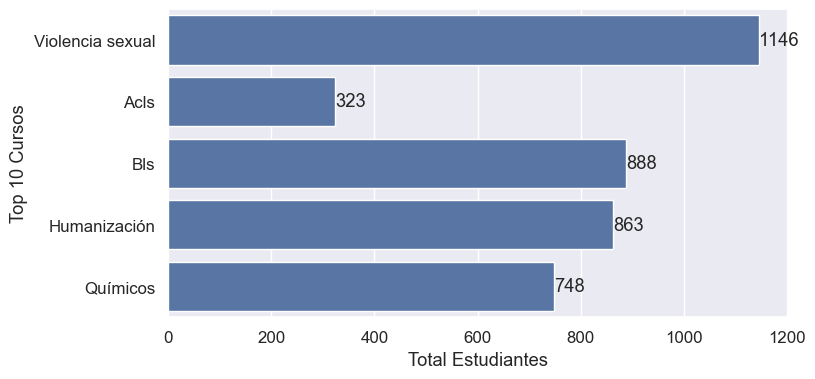

In [172]:
# Show students quantity by course, showing top 10

plt.figure(figsize=(8,4))

ax = sns.barplot(
    data=resumen_cursos,
    x = 'total_estudiantes',
    y = 'CURSO'
)


for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.xlabel('Total Estudiantes')
plt.xticks(rotation=0)

plt.ylabel('Top 10 Cursos')

plt.show()

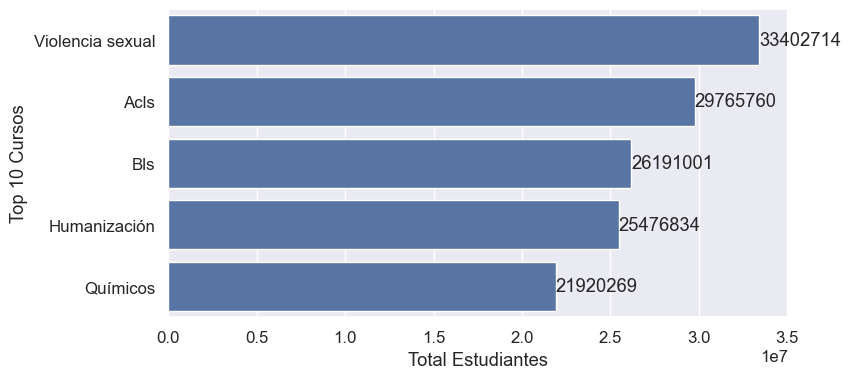

In [173]:
# Show students quantity by course, showing top 10

plt.figure(figsize=(8,4))

ax = sns.barplot(
    data=resumen_cursos,
    x = 'total_ventas',
    y = 'CURSO'
)


for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.xlabel('Total Estudiantes')
plt.xticks(rotation=0)

plt.ylabel('Top 10 Cursos')

plt.show()

In [174]:
resumen_cursos_tiempo = df_fv.groupby(['ANIO_VENTA','CURSO']).agg(
    total_estudiantes = ('NUMERO_DE_IDENTIFICACION', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_ventas = ('PRECIO_NETO', 'sum')

).round(2).reset_index().sort_values(by=['ANIO_VENTA','total_ventas'], ascending=False)

resumen_cursos_tiempo

,ANIO_VENTA,CURSO,total_estudiantes,ticket_promedio,total_ventas
102,2026,Humanización,318,29366.25,9338466.64
127,2026,Violencia sexual,276,27155.68,7494966.64
115,2026,Primeros auxilios,137,43563.50,5968200.00
117,2026,Químicos,201,27104.31,5447966.64
100,2026,Duelo,178,26986.89,4803666.64
...,...,...,...,...,...
3,2024,Adulto mayor,1,35000.00,35000.00
11,2024,Dea,2,15000.00,30000.00
12,2024,Discapacidad,1,25000.00,25000.00
20,2024,Liderazgo,1,0.00,0.00


In [175]:
top5_ventas = (
    resumen_cursos_tiempo
    .groupby('ANIO_VENTA', group_keys=False)
    .apply(lambda x: x.nlargest(5, 'total_ventas'))
)

top5_ventas

C:\Users\Hugo\AppData\Local\Temp\ipykernel_14396\1993104132.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'total_ventas'))


,ANIO_VENTA,CURSO,total_estudiantes,ticket_promedio,total_ventas
38,2024,Violencia sexual,442,29547.01,13059779.00
0,2024,Acls,115,95747.83,11011000.00
6,2024,Bls,327,30198.17,9874802.00
14,2024,Duelo,269,30385.74,8173764.00
30,2024,Químicos,263,29738.28,7821167.00
39,2025,Acls,161,93338.26,15027460.00
83,2025,Violencia sexual,428,30018.62,12847969.33
45,2025,Bls,393,31015.86,12189233.33
58,2025,Humanización,358,31027.66,11107903.33
73,2025,Químicos,284,30461.75,8651136.33


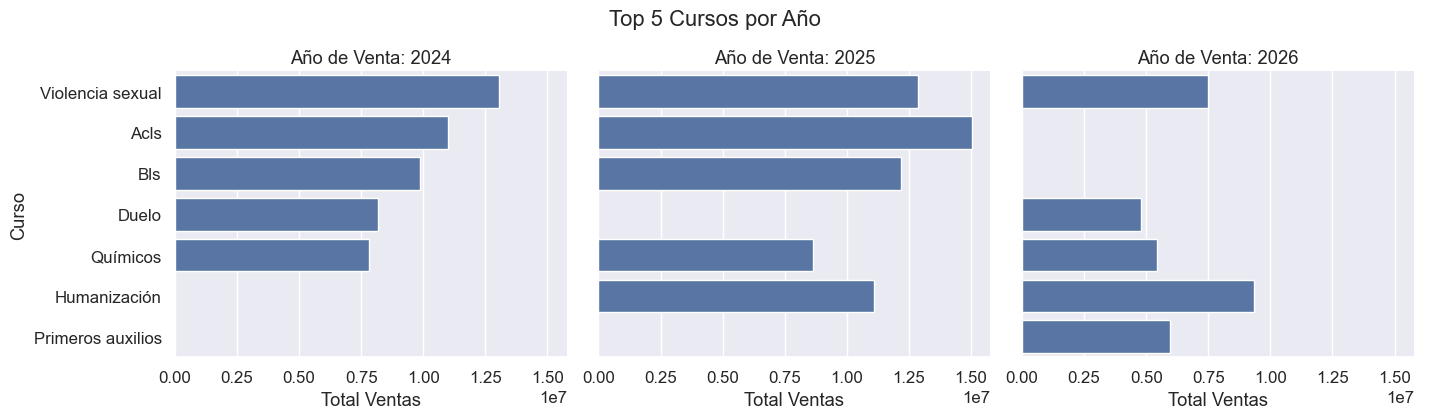

In [176]:
g = sns.catplot(
    data=top5_ventas,
    x='total_ventas',
    y='CURSO',
    col='ANIO_VENTA',
    kind='bar',
    height=4,
    aspect=1.2
)


for ax in g.axes.flat:
    title = ax.get_title()

    ax.set_title(title.replace("ANIO_VENTA = ", "Año de Venta: "))


g.set_axis_labels("Total Ventas", "Curso")


g.fig.suptitle("Top 5 Cursos por Año", y=1.05)

plt.show()

#### ¿Que cursos generan mas ingresos?

Con el anterior estudio se puede afirmar que los cursos que mas ingresos han representado para CC entre el periodo de 2024 a 2026 son:

1.  Violencia sexual con 1146 estudiantes y un total vendido de: 33,402,714.97
2.	Acls con 323 estudiantes y un total vendido de: 29,765,760.00
3.	Bls	con 888 estudiantes y un total vendido de: 26,191,001.97
4.	Humanización con 863 estudiantes y un total vendido de: 25,476,834.97
5.	Químicos con 748 estudiantes y un total vendido de: 21,920,269.97

Los cursos mas consistentes en ventas en estos tres periodos 2024,2025 y 2026 son

1. Violencia sexual
2. Quimicos

Se observa que el curso de ACLS es el que con menor numero de ventas mayor cantidad de ingresos genera al tener un ticket promedio de venta mas alto en un promedio de $94,000 COP


## 2. ¿Que perfil de cliente compra mas?

In [177]:
# How many studenst betwen 2024 and 2026 CCS has?

len(df_fv['NUMERO_DE_IDENTIFICACION'].unique())

2920

In [178]:
# Leaving unique students on DB
df_fv_clientes = df_fv.drop_duplicates(subset=['NUMERO_DE_IDENTIFICACION'], keep='last')

In [179]:
len(df_fv_clientes['NUMERO_DE_IDENTIFICACION'])

2920

In [180]:
# Percentage of unknown registers on 'GENERO' column

(df_fv.loc[df_fv['GENERO'] == 'UNKNOWN']['NUMERO_DE_IDENTIFICACION'].count() * 100) / df_fv['NUMERO_DE_IDENTIFICACION'].count()


np.float64(24.649350649350648)

In [181]:
#

df_fv_clientes['GENERO'].value_counts()

GENERO
Femenino     1497
UNKNOWN       854
Masculino     569
Name: count, dtype: int64

<Axes: xlabel='EDAD', ylabel='Density'>

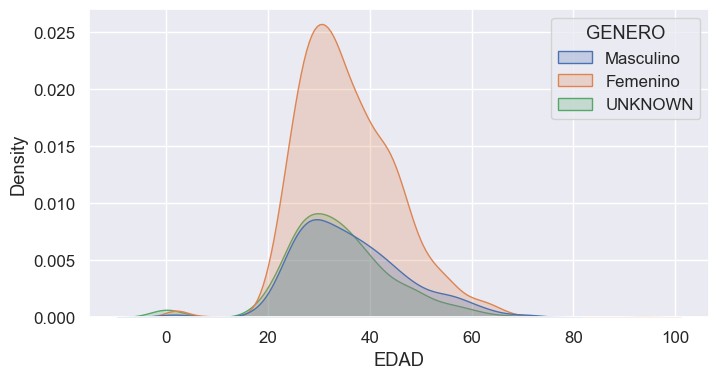

In [182]:
plt.figure(figsize=(8,4))
sns.kdeplot(
    data=df_fv_clientes,
    x='EDAD',
    hue='GENERO',
    fill=True
)

In [183]:
df_fv_clientes['GRUPO_EDAD'].value_counts()

GRUPO_EDAD
Adulto    1172
Joven      700
Senior     167
Menor       15
Name: count, dtype: int64

In [184]:
resumen_clientes = df_fv_clientes.groupby(['GRUPO_EDAD', 'GENERO']).agg(
    numero_estudiantes = ('GENERO', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index()

resumen_clientes

,GRUPO_EDAD,GENERO,numero_estudiantes,ticket_promedio,total_vendido
0,Adulto,Femenino,695,35960.621583,24992632.00
1,Adulto,Masculino,247,36528.627530,9022571.00
2,Adulto,UNKNOWN,230,27382.608696,6298000.00
3,Joven,Femenino,394,37720.726726,14861966.33
4,Joven,Masculino,145,37308.275862,5409700.00
5,Joven,UNKNOWN,161,39571.428571,6371000.00
6,Menor,Femenino,9,38955.555556,350600.00
7,Menor,Masculino,4,23750.000000,95000.00
8,Menor,UNKNOWN,2,45250.000000,90500.00
9,Senior,Femenino,90,34033.333333,3063000.00


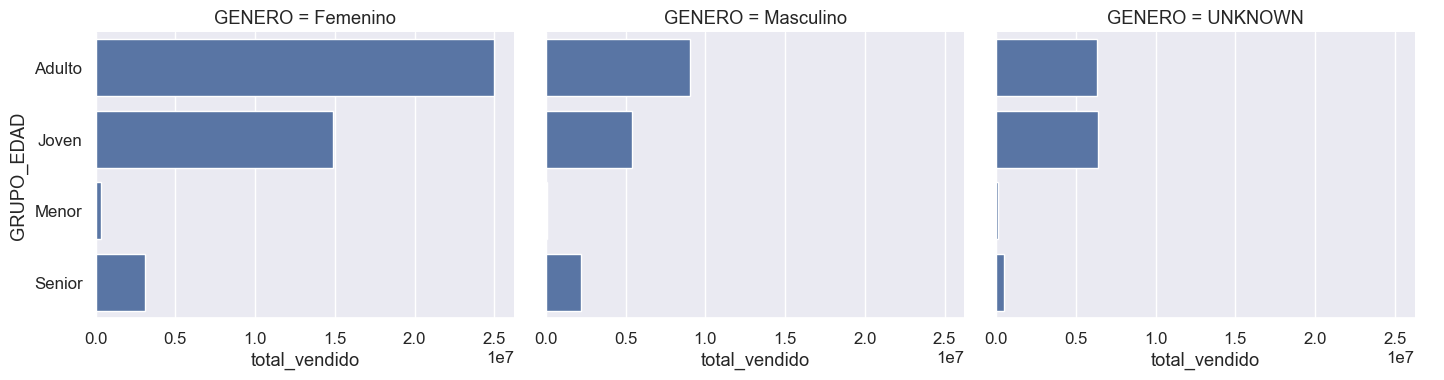

In [191]:
g = sns.catplot(
    data=resumen_clientes,
    x='total_vendido',
    y='GRUPO_EDAD',
    col='GENERO',
    kind='bar',
    height=4,
    aspect=1.2
)

In [185]:
resumen_clientes_region = df_fv_clientes.groupby(['CIUDAD_REGION', 'GENERO']).agg(
    numero_estudiantes = ('GENERO', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index()

resumen_clientes_region

,CIUDAD_REGION,GENERO,numero_estudiantes,ticket_promedio,total_vendido
0,Pasto - Nariño,Femenino,1496,34627.553697,51802820.33
1,Pasto - Nariño,Masculino,569,34872.282953,19842329.00
2,Pasto - Nariño,UNKNOWN,685,26952.310423,18462332.64
3,Tumaco - Nariño,UNKNOWN,74,0.000000,0.00
4,UNKNOWN,Femenino,1,30000.000000,30000.00
5,UNKNOWN,UNKNOWN,95,38526.315789,3660000.00


In [193]:
resumen_clientes_procedencia = df_fv_clientes.groupby(['PROCEDENCIA', 'GENERO']).agg(
    numero_estudiantes = ('GENERO', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index().sort_values(by=['numero_estudiantes', 'total_vendido'], ascending=False)

resumen_clientes_procedencia

,PROCEDENCIA,GENERO,numero_estudiantes,ticket_promedio,total_vendido
6,Facebook,Femenino,1332,34915.781029,46507820.33
7,Facebook,Masculino,519,35213.543353,18275829.00
2,Alianzas comerciales,UNKNOWN,357,23955.648852,8552166.64
8,Facebook,UNKNOWN,265,16851.569811,4465666.00
17,UNKNOWN,UNKNOWN,147,39812.925170,5852500.00
0,Alianzas comerciales,Femenino,63,28698.412698,1808000.00
15,UNKNOWN,Femenino,58,34396.551724,1995000.00
5,Cliente antiguo,UNKNOWN,36,29722.222222,1070000.00
11,Recomendación de compañero,UNKNOWN,28,42000.000000,1176000.00
3,Cliente antiguo,Femenino,28,34071.428571,954000.00


In [196]:
resumen_clientes_mediodepago = df_fv_clientes.groupby(['MEDIO_DE_PAGO', 'GRUPO_EDAD']).agg(
    numero_estudiantes = ('GENERO', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index().sort_values(by=['numero_estudiantes', 'ticket_promedio', 'total_vendido'], ascending=False)

resumen_clientes_mediodepago

,MEDIO_DE_PAGO,GRUPO_EDAD,numero_estudiantes,ticket_promedio,total_vendido
23,Nequi,Adulto,535,37699.685981,20169332.00
24,Nequi,Joven,321,41368.638629,13279333.00
2,Bancolombia,Adulto,164,35399.823171,5805571.00
40,Transferencia Bancaria Bancolombia,Adulto,130,31884.615385,4145000.00
44,UNKNOWN,Adulto,114,10333.333333,1178000.00
3,Bancolombia,Joven,100,34730.000000,3473000.00
41,Transferencia Bancaria Bancolombia,Joven,91,35131.868132,3197000.00
26,Nequi,Senior,83,35834.939759,2974300.00
15,Daviplata,Adulto,82,41003.658537,3362300.00
7,Caja,Adulto,80,47475.000000,3798000.00


#### ¿Que perfil de cliente compra mas?

Con el anterior estudio se puede afirmar que el perfil de cleinte que mas a generado ingresos para CCS entre el periodo de 2024 a 2026 es:

1. Un perfil femenino entre los 30 y 50 años, principalmente ubicado en Pasto, principal mente ha llegado a CCS por medio de facebook y su metodo de pago preferencial es NEQUI o BANCOLOMBIA

## ¿Qué responsables comerciales venden mejor?

In [206]:
resumen_vendedor = df_fv.groupby(['RESPONSABLE_VENTA']).agg(
    total_ventas = ('NUMERO_DE_IDENTIFICACION', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index().sort_values(by=['total_ventas'], ascending=False).head(6)

resumen_vendedor

,RESPONSABLE_VENTA,total_ventas,ticket_promedio,total_vendido
3,Ccs,3708,37046.003501,1.373666e+08
27,Proinsalud,1250,25706.400000,3.213300e+07
33,Yurani,925,29467.675676,2.725760e+07
17,Lucio Francisco Rosero Muñoz,395,21302.104177,8.414331e+06
14,Ipiales,344,26613.372093,9.155000e+06
18,Luis Olivares Pinta Lopez,195,29923.066667,5.834998e+06


In [211]:
resumen_vendedor = df_fv.groupby(['ANIO_VENTA','RESPONSABLE_VENTA']).agg(
    total_ventas = ('NUMERO_DE_IDENTIFICACION', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index().sort_values(by=['ANIO_VENTA','total_ventas'], ascending=(True,False))

resumen_vendedor

,ANIO_VENTA,RESPONSABLE_VENTA,total_ventas,ticket_promedio,total_vendido
3,2024,Ccs,835,42787.056287,35727192.00
27,2024,Yurani,451,29932.594235,13499600.00
16,2024,Luis Olivares Pinta Lopez,120,28816.650000,3457998.00
15,2024,Lucio Francisco Rosero Muñoz,116,20698.258621,2400998.00
11,2024,H. Divino Niño,84,32142.904762,2700004.00
23,2024,Proinsalud,76,25921.052632,1970000.00
12,2024,H. San Pedro,67,39805.970149,2667000.00
8,2024,Fatima,52,20000.000000,1040000.00
2,2024,Brayan,51,37059.156863,1890017.00
17,2024,Marcela Pinzon,40,1875.000000,75000.00


#### ¿Qué responsables comerciales venden mejor?

Con el anterior estudio se puede afirmar que el perfil de vendedor  que mas ha generado ingresos para CCS entre el periodo de 2024 a 2026 es:

1. Yurani Daniela Goyes Mora con 925 ventas
2. Lucio Francisco Rosero Muñoz con 395 ventas
3. Luis Olivares Pinta Lopez con 195 ventas

